# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.50MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.0179, -0.5847,  0.5090,  0.0241,  0.7022,  0.3586, -0.8795,  0.2748,
         -0.5164,  0.4079]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/5], Train Loss: 0.4126, Train Acc: 0.8824, Val Loss: 0.3100, Val Acc: 0.9102
Epoch [2/5], Train Loss: 0.3166, Train Acc: 0.9100, Val Loss: 0.2847, Val Acc: 0.9172
Epoch [3/5], Train Loss: 0.2993, Train Acc: 0.9156, Val Loss: 0.2765, Val Acc: 0.9192
Epoch [4/5], Train Loss: 0.2916, Train Acc: 0.9172, Val Loss: 0.2780, Val Acc: 0.9178
Epoch [5/5], Train Loss: 0.2856, Train Acc: 0.9204, Val Loss: 0.2773, Val Acc: 0.9182


In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2856
Última acurácia de treinamento: 0.9204
Última perda de validação: 0.2773
Última acurácia de validação: 0.9182


### Visualizando a evolução da perda e acurácia

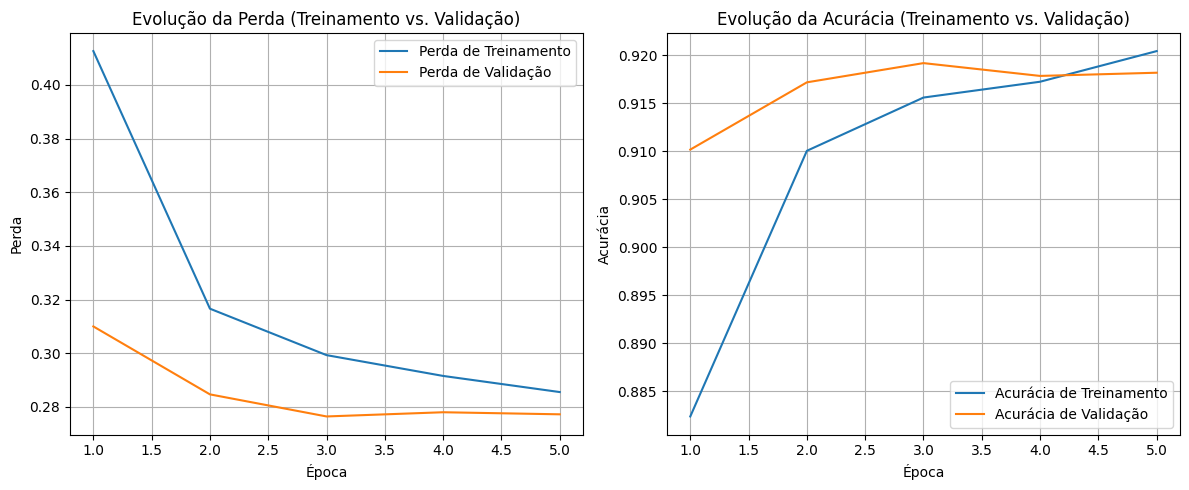

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
2. Em uma época, quantos mini-batches existem?
3. Qual é a definição de época?

1.   O tamanho do mini-batch é 100  
2.   Para o conjunto de treinamento, existem 480 mini-batches por época. Para o conjunto de validação, existem 120 mini-batches por época.
3.  Uma época (epoch) é uma passagem completa de todo o conjunto de dados de treinamento através do algoritmo de aprendizado. Durante uma época, o modelo vê cada amostra do conjunto de treinamento uma vez.

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.


--- Training with batch_size: 32 ---
Época: 1/5, Train Loss: 0.3943, Tempo: 6.02s
Época: 2/5, Train Loss: 0.3276, Tempo: 6.62s
Época: 3/5, Train Loss: 0.3125, Tempo: 5.94s
Época: 4/5, Train Loss: 0.3087, Tempo: 6.55s
Época: 5/5, Train Loss: 0.3011, Tempo: 5.90s

--- Training with batch_size: 128 ---
Época: 1/5, Train Loss: 0.4263, Tempo: 5.59s
Época: 2/5, Train Loss: 0.3203, Tempo: 4.94s
Época: 3/5, Train Loss: 0.3033, Tempo: 5.42s
Época: 4/5, Train Loss: 0.2946, Tempo: 5.16s
Época: 5/5, Train Loss: 0.2886, Tempo: 5.02s

--- Training with batch_size: 512 ---
Época: 1/5, Train Loss: 0.5852, Tempo: 5.62s
Época: 2/5, Train Loss: 0.3779, Tempo: 4.71s
Época: 3/5, Train Loss: 0.3461, Tempo: 5.26s
Época: 4/5, Train Loss: 0.3302, Tempo: 4.71s
Época: 5/5, Train Loss: 0.3187, Tempo: 5.00s


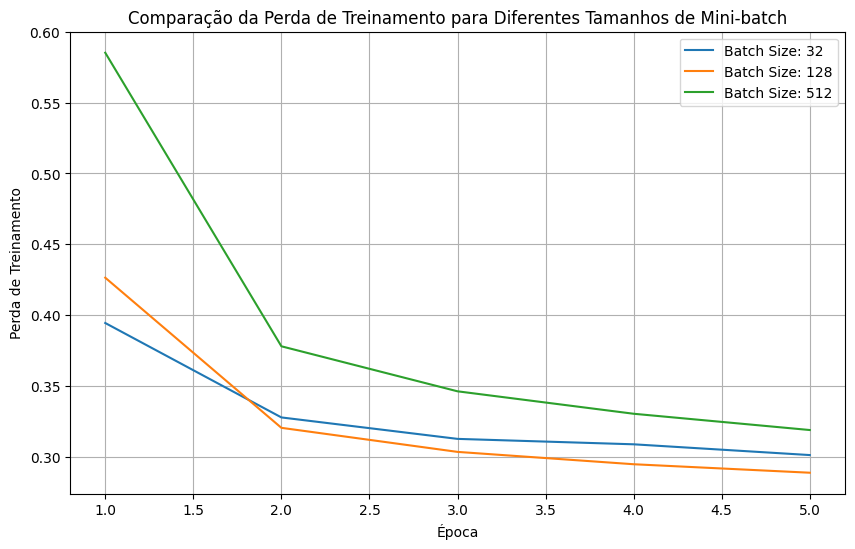

In [14]:
import time # Import the time module

batch_sizes_to_test = [32, 128, 512]
n_epochs = 5
learningRate = 0.5

all_train_losses_by_batch_size = {}

for current_batch_size in batch_sizes_to_test:
    print(f"\n--- Training with batch_size: {current_batch_size} ---")

    # Re-create DataLoaders with the current batch size
    loader_train = DataLoader(dataset_train, batch_size=current_batch_size, shuffle=True)

    # Re-initialize model, criterion, and optimizer for each new batch size experiment
    model = torch.nn.Linear(28*28, 10)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

    train_losses_per_epoch = []

    for epoch in range(n_epochs):
        start_time = time.time() # Record start time for the epoch
        model.train() # Set model to training mode
        running_train_loss = 0.0

        n_batches_train = len(loader_train)

        for i, (x_train, y_train) in enumerate(loader_train):
            inputs = Variable(x_train.view(-1, 28 * 28))
            labels = Variable(y_train)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            # Print after each mini-batch as requested
            print(f'Época: {epoch+1}/{n_epochs}, batch: {i+1}/{n_batches_train}', end='\r')

        avg_train_loss = running_train_loss / n_batches_train
        train_losses_per_epoch.append(avg_train_loss)
        end_time = time.time() # Record end time for the epoch
        epoch_duration = end_time - start_time
        print(f'Época: {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.4f}, Tempo: {epoch_duration:.2f}s') # Newline and time after epoch print

    all_train_losses_by_batch_size[current_batch_size] = train_losses_per_epoch

# Plotting the comparison of training losses
plt.figure(figsize=(10, 6))
for batch_size_val, losses in all_train_losses_by_batch_size.items():
    plt.plot(range(1, n_epochs + 1), losses, label=f'Batch Size: {batch_size_val}')

plt.xlabel('Época')
plt.ylabel('Perda de Treinamento')
plt.title('Comparação da Perda de Treinamento para Diferentes Tamanhos de Mini-batch')
plt.legend()
plt.grid(True)
plt.show()

O gráfico revela um trade-off clássico entre tamanho de batch, qualidade do gradiente e velocidade de convergência.

**Convergência**

O batch 32 começa com a menor loss inicial (0.394) porque gradientes calculados em batches pequenos têm mais ruído, o que paradoxalmente ajuda a escapar de regiões ruins logo no início. O batch 512 começa muito pior (0.585) porque com poucos updates por época o modelo aprende menos por passagem completa nos dados.

Ao final das 5 épocas, o batch 128 atinge a menor loss (0.289), sugerindo que é o ponto de equilíbrio ideal entre ruído do gradiente e estabilidade nesse dataset.

**Velocidade por época vs. convergência real**

| Batch | Loss final | Tempo total | Updates/época |
|-------|-----------|-------------|---------------|
| 32 | 0.301 | ~31s | ~677 |
| 128 | 0.289 | ~26s | ~170 |
| 512 | 0.319 | ~25s | ~43 |

O batch 512 é o mais rápido por época, mas faz muito menos atualizações de peso — por isso converge mais devagar em termos de loss. O batch 32 é o mais lento por época e ainda assim não atingiu a melhor loss final.

**Conclusão prática**

Com apenas 5 épocas, o batch 128 foi o mais eficiente: menor tempo total e melhor loss final. O batch 32 provavelmente alcançaria uma loss similar ou melhor com mais épocas, mas ao custo de mais tempo. O batch 512 precisaria de significativamente mais épocas para competir.

## Conclusões sobre os experimentos deste notebook
